In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('classic')
parameters = { 'figure.figsize': (15, 15), 'legend.scatterpoints': 1,
               'axes.labelsize': 50,       'axes.labelpad': 15,
               'font.size': 30,            'lines.linewidth': 4,
               'xtick.major.width': 2,     'xtick.major.size': 10.0,
               'ytick.major.width': 2,     'ytick.major.size': 10.0,
               'xtick.minor.visible': True,'ytick.minor.visible': True,
               'xtick.minor.width': 1,     'xtick.minor.size': 5.0,
               'ytick.minor.width': 1,     'ytick.minor.size': 5.0,
               'axes.titlepad': 20.0}
plt.rcParams.update(parameters)

In [2]:
#rho = 0.3003
eta = 0.3

In [3]:
def a1():
    return eta / (1 - eta)**2 * (1.55707 - 1.85633*eta)
def a2():
    return eta / (1 - eta) * (1.28127 - 1.82134*eta)
def a3():
    return 0.74480 - 0.93453*eta
def a4():
    return 1.17102 - 0.68230*eta
def a5():
    return 0.15975/eta**3
def a6():
    return 2.69757-0.86987*eta

In [4]:
def A_2():
    return np.pi/ ( a6() - a4() - 1 )
def A_1():
    return ( a1() + a2() * a4() ) * ( a4() - a3() )*( a4() + 1 )/(A_2() * a3() * a4())

In [5]:
#r-grid
N_bins = 2048
R_max = 25
del_r = R_max/N_bins
r_array = np.linspace(del_r/2,R_max-del_r/2,N_bins)

In [6]:
b = np.zeros(N_bins)
for i in range(N_bins):
    if(r_array[i] < a4()+1 or r_array[i] == a4()+1 ):
        b[i] = ( a1() + a2() * ( r_array[i] - 1 ) ) * ( r_array[i] - 1 - a3() ) * ( r_array[i] - 1 - a4() )/( a3()*a4() )
    else:
        b[i] = A_1()/r_array[i] * np.exp( - a5() * ( r_array[i] - 1 - a4() ) ) * np.sin(A_2()*(r_array[i] -1 - a4()))
        
B_r = b*b

(1, 2.25)

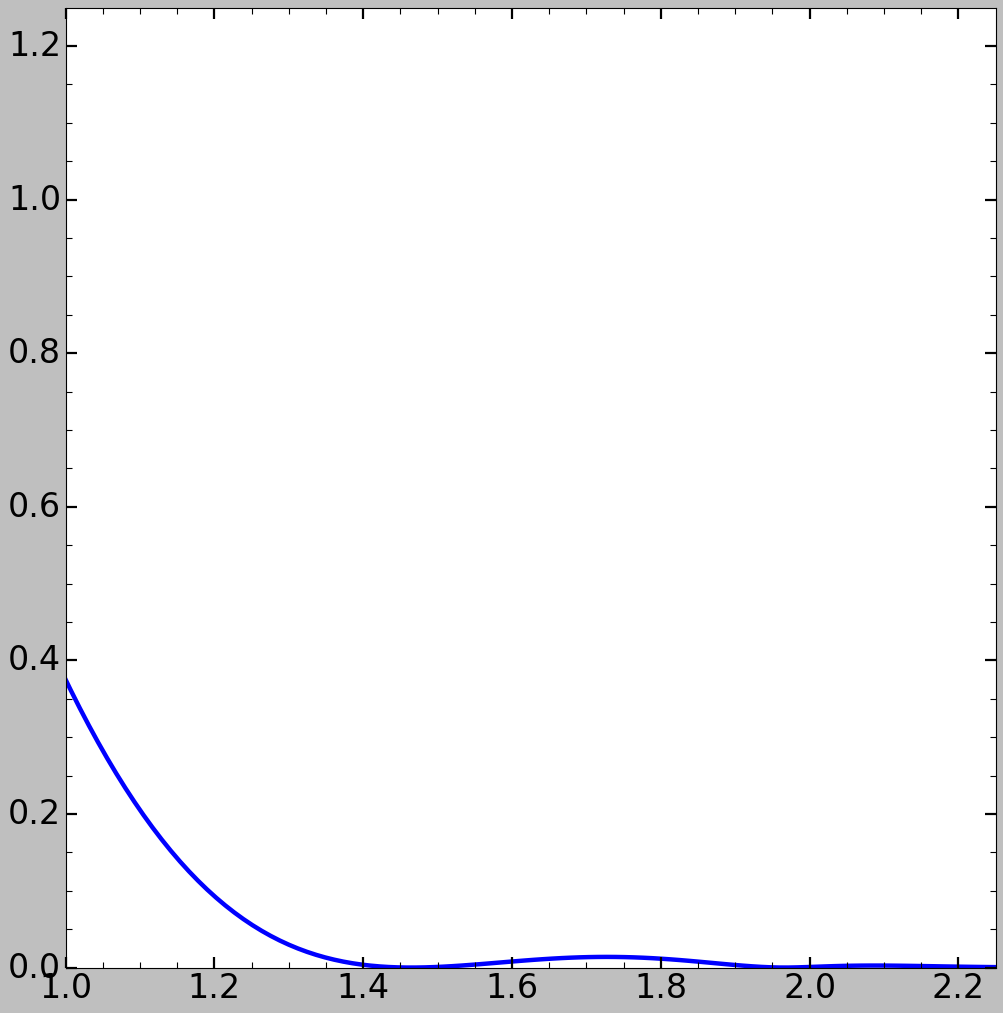

In [7]:
plt.plot(r_array,B_r,linewidth=4)
plt.ylim(0,1.25)
plt.xlim(1,2.25)

In [8]:
#bridge_data = np.array([r_array,B_r]).T
#np.savetxt('bridge_parametrical_eta0p3_Nbins2048.out',bridge_data)